In [13]:
import pandas as pd
import numpy as np
import re
import emoji
import html
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
)
import torch

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## Config

In [14]:
MAX_ROWS   = 300_000
MAX_LENGTH = 128
BATCH_SIZE = 64

MODELS = {
    'BERT':             '../models_new/bert-base-uncased',
    'DistilBERT':       '../models_new/distilbert-base-uncased',
    'BERTweet':         '../models_new/bertweet-base',
    'Twitter-RoBERTa':  '../models_new/twitter-roberta-base',
}

COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

## Recreate Identical Test Split

In [15]:
def preprocessing(text: str):
    text = html.unescape(text)
    text = re.sub(r'^RT\s+', '', text)
    text = re.sub(r'http\S+|www\.\S+', 'HTTPURL', text)
    text = re.sub(r'@\w+', '@USER', text)
    text = emoji.demojize(text, delimiters=(' ', ' '))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = pd.read_csv('twitter_dataset.csv')
df = df.drop(columns=['Unnamed: 0'])
df = df.drop_duplicates()
df = df.dropna(subset=['sentiment'])
df = df[df['sentiment'] != 2]
df['sentiment'] = df['sentiment'].astype(int)
df['tweet'] = df['tweet'].apply(preprocessing)

df_compressed, _ = train_test_split(df, train_size=MAX_ROWS, stratify=df['sentiment'], random_state=21)
df_train, df_temp = train_test_split(df_compressed, test_size=0.2, stratify=df_compressed['sentiment'], random_state=21)
df_val,   df_test = train_test_split(df_temp,        test_size=0.5, stratify=df_temp['sentiment'],        random_state=21)

print(f'Train : {len(df_train):,}')
print(f'Val   : {len(df_val):,}')
print(f'Test  : {len(df_test):,}')

Train : 240,000
Val   : 30,000
Test  : 30,000


In [16]:
def to_hf_dataset(df):
    ds = Dataset.from_pandas(df[['tweet', 'sentiment']].reset_index(drop=True))
    return ds.rename_columns({'tweet': 'text', 'sentiment': 'label'})

hf_test = to_hf_dataset(df_test)
print(hf_test)

Dataset({
    features: ['text', 'label'],
    num_rows: 30000
})


## Run Inference on All Models

In [17]:
results = {}

for name, path in MODELS.items():
    print(f'\n{"="*50}')
    print(f'  {name}  ({path})')
    print(f'{"="*50}')

    tokenizer = AutoTokenizer.from_pretrained(path)
    model     = AutoModelForSequenceClassification.from_pretrained(path)

    tok_test = hf_test.map(
        lambda x: tokenizer(x['text'], truncation=True, max_length=MAX_LENGTH),
        batched=True,
    )

    trainer = Trainer(
        model         = model,
        args          = TrainingArguments(
            output_dir                 = './tmp_eval',
            per_device_eval_batch_size = BATCH_SIZE,
            fp16                       = True,
        ),
        data_collator = DataCollatorWithPadding(tokenizer),
    )

    preds  = trainer.predict(tok_test)
    logits = preds.predictions
    y_true = preds.label_ids
    y_pred = np.argmax(logits, axis=-1)
    probs  = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
    y_prob = probs[:, 1]

    results[name] = {
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

    del model, trainer, tokenizer, tok_test
    torch.cuda.empty_cache()
    print(f'{name} done.')


  BERT  (../models_new/bert-base-uncased)


Map: 100%|██████████| 30000/30000 [00:01<00:00, 18950.57 examples/s]


BERT done.

  DistilBERT  (../models_new/distilbert-base-uncased)


Map: 100%|██████████| 30000/30000 [00:00<00:00, 59516.89 examples/s]


DistilBERT done.

  BERTweet  (../models_new/bertweet-base)


Map: 100%|██████████| 30000/30000 [00:03<00:00, 8463.49 examples/s]


BERTweet done.

  Twitter-RoBERTa  (../models_new/twitter-roberta-base)


Map: 100%|██████████| 30000/30000 [00:00<00:00, 53951.28 examples/s]


Twitter-RoBERTa done.


## Classification Reports

In [18]:
for name, res in results.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(res['y_true'], res['y_pred'], target_names=['negative', 'positive']))


  BERT
              precision    recall  f1-score   support

    negative       0.85      0.86      0.86     15027
    positive       0.86      0.85      0.85     14973

    accuracy                           0.86     30000
   macro avg       0.86      0.86      0.86     30000
weighted avg       0.86      0.86      0.86     30000


  DistilBERT
              precision    recall  f1-score   support

    negative       0.84      0.86      0.85     15027
    positive       0.85      0.84      0.85     14973

    accuracy                           0.85     30000
   macro avg       0.85      0.85      0.85     30000
weighted avg       0.85      0.85      0.85     30000


  BERTweet
              precision    recall  f1-score   support

    negative       0.87      0.88      0.88     15027
    positive       0.88      0.87      0.88     14973

    accuracy                           0.88     30000
   macro avg       0.88      0.88      0.88     30000
weighted avg       0.88      0.88      0

## Confusion Matrices

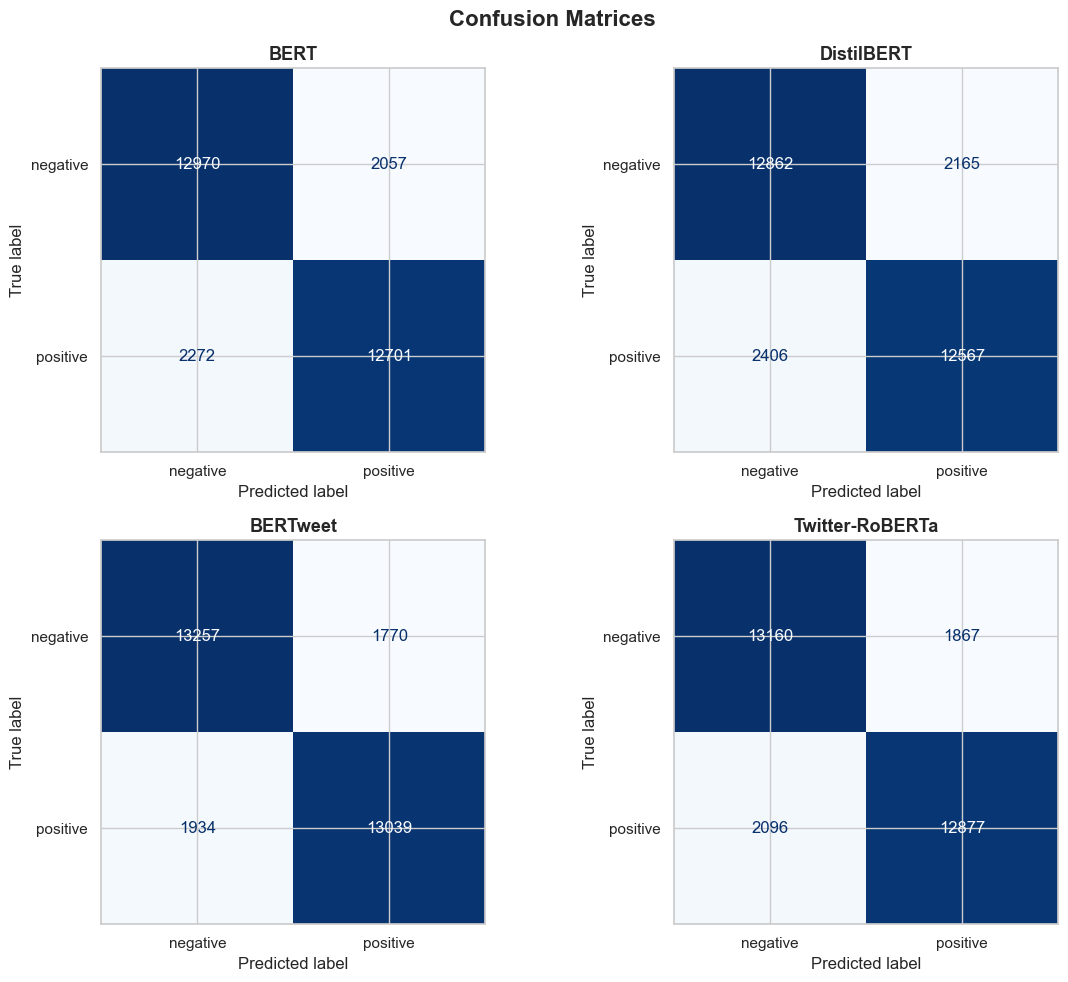

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm   = confusion_matrix(res['y_true'], res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative', 'positive'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## ROC Curves

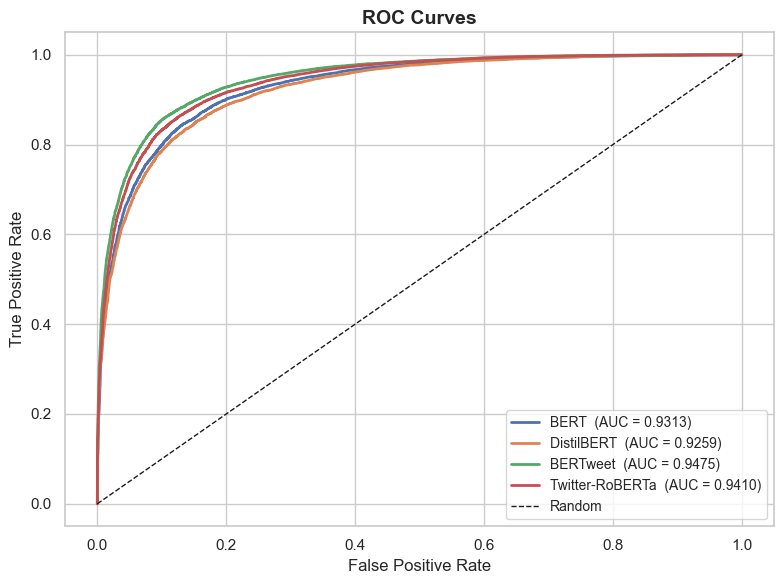

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, res), color in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(res['y_true'], res['y_prob'])
    auc         = roc_auc_score(res['y_true'], res['y_prob'])
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Aggregate Metrics

In [21]:
rows = []
for name, res in results.items():
    f1_per_class = f1_score(res['y_true'], res['y_pred'], average=None)
    rows.append({
        'Model'       : name,
        'Accuracy'    : accuracy_score(res['y_true'], res['y_pred']),
        'F1 Macro'    : f1_score(res['y_true'], res['y_pred'], average='macro'),
        'F1 Negative' : f1_per_class[0],
        'F1 Positive' : f1_per_class[1],
        'Precision'   : precision_score(res['y_true'], res['y_pred'], average='macro'),
        'Recall'      : recall_score(res['y_true'], res['y_pred'], average='macro'),
        'ROC AUC'     : roc_auc_score(res['y_true'], res['y_prob']),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
metrics_df.style.format('{:.4f}').highlight_max(axis=0, color='#c6efce').highlight_min(axis=0, color='#ffc7ce')

,Accuracy,F1 Macro,F1 Negative,F1 Positive,Precision,Recall,ROC AUC
Model,,,,,,,
BERT,0.8557,0.8557,0.8570,0.8544,0.8558,0.8557,0.9313
DistilBERT,0.8476,0.8476,0.8491,0.8461,0.8477,0.8476,0.9259
BERTweet,0.8765,0.8765,0.8774,0.8756,0.8766,0.8765,0.9475
Twitter-RoBERTa,0.8679,0.8679,0.8691,0.8666,0.8680,0.8679,0.9410


## Model Comparison Charts

C:\Users\torbob\AppData\Local\Temp\ipykernel_17416\1111571517.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
C:\Users\torbob\AppData\Local\Temp\ipykernel_17416\1111571517.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
C:\Users\torbob\AppData\Local\Temp\ipykernel_17416\1111571517.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)


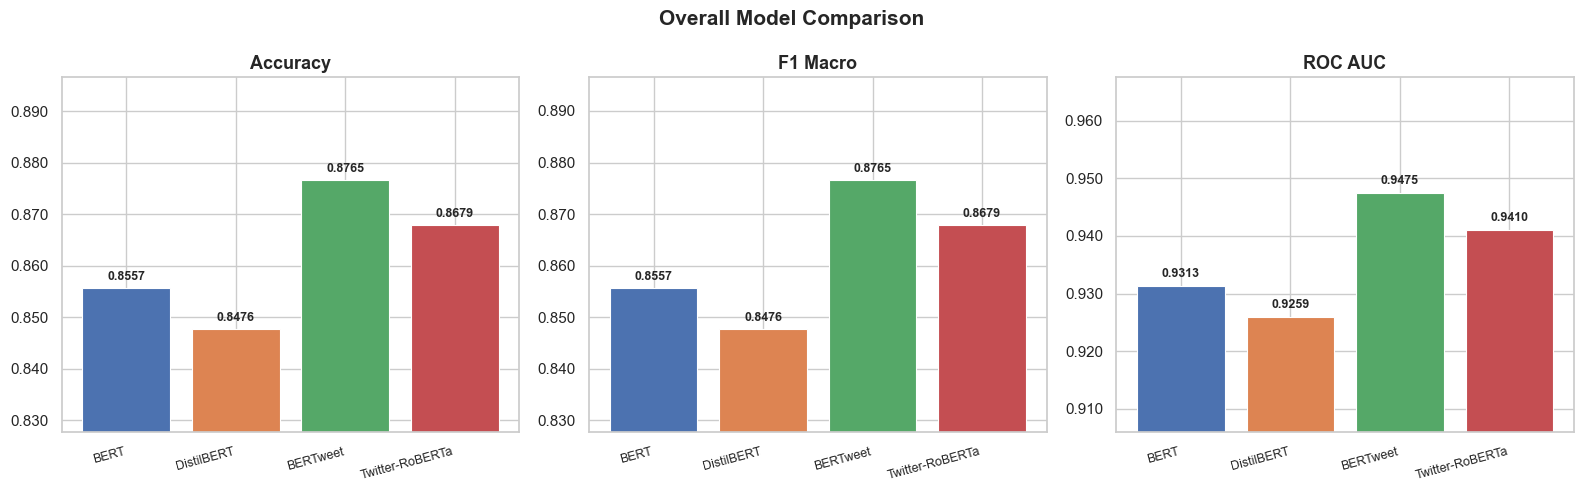

In [22]:
top_metrics = ['Accuracy', 'F1 Macro', 'ROC AUC']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, top_metrics):
    vals = metrics_df[metric]
    bars = ax.bar(vals.index, vals.values, color=COLORS, edgecolor='white', linewidth=0.8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(vals.min() - 0.02, vals.max() + 0.02)
    ax.set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    for bar, v in zip(bars, vals.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

plt.suptitle('Overall Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

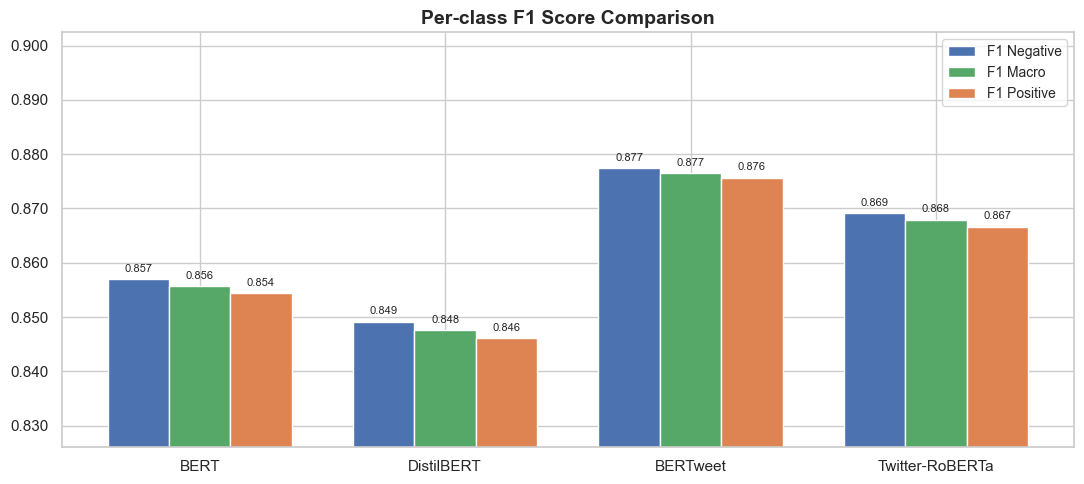

In [23]:
x     = np.arange(len(metrics_df))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - width, metrics_df['F1 Negative'], width, label='F1 Negative', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x,         metrics_df['F1 Macro'],    width, label='F1 Macro',    color='#55A868', edgecolor='white')
b3 = ax.bar(x + width, metrics_df['F1 Positive'], width, label='F1 Positive', color='#DD8452', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, fontsize=11)
ax.set_ylim(metrics_df[['F1 Negative','F1 Macro','F1 Positive']].values.min() - 0.02,
            metrics_df[['F1 Negative','F1 Macro','F1 Positive']].values.max() + 0.025)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.set_title('Per-class F1 Score Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.show()

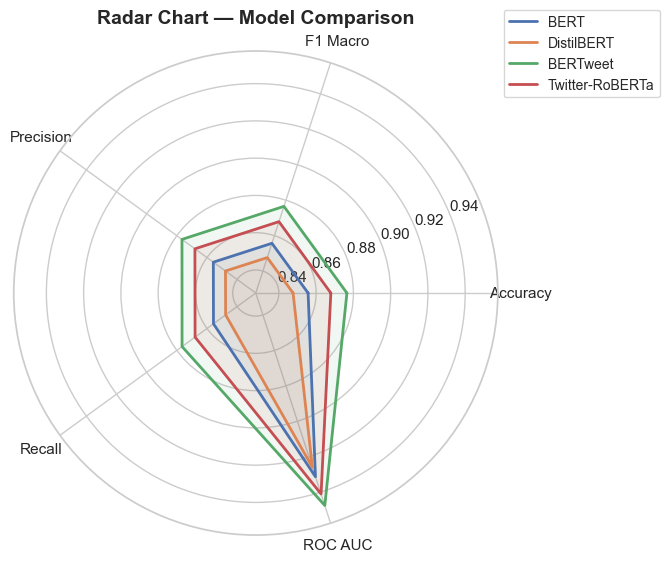

In [24]:
radar_metrics = ['Accuracy', 'F1 Macro', 'Precision', 'Recall', 'ROC AUC']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for (name, row), color in zip(metrics_df[radar_metrics].iterrows(), COLORS):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
vmin = metrics_df[radar_metrics].values.min() - 0.02
vmax = metrics_df[radar_metrics].values.max() + 0.01
ax.set_ylim(vmin, vmax)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_title('Radar Chart — Model Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

## Multi-Seed Stability Test

Re-evaluate all models on **5 different random test splits** (seeds: 21, 42, 7, 99, 123) to check whether the seed-21 results were lucky or genuinely consistent.

In [25]:
SEEDS = [21, 42, 7, 99, 123]

seed_records = []

for seed in SEEDS:
    print(f'\n{"#"*60}')
    print(f'  SEED = {seed}')
    print(f'{"#"*60}')

    df_c, _       = train_test_split(df, train_size=MAX_ROWS, stratify=df['sentiment'], random_state=seed)
    df_tr, df_tmp = train_test_split(df_c,  test_size=0.2,  stratify=df_c['sentiment'],  random_state=seed)
    df_v,  df_te  = train_test_split(df_tmp, test_size=0.5, stratify=df_tmp['sentiment'], random_state=seed)
    hf_te = to_hf_dataset(df_te)

    for name, path in MODELS.items():
        print(f'  -> {name}', end=' ... ', flush=True)

        tokenizer = AutoTokenizer.from_pretrained(path)
        model     = AutoModelForSequenceClassification.from_pretrained(path)

        tok_te = hf_te.map(
            lambda x: tokenizer(x['text'], truncation=True, max_length=MAX_LENGTH),
            batched=True,
        )

        trainer = Trainer(
            model         = model,
            args          = TrainingArguments(
                output_dir                 = './tmp_eval',
                per_device_eval_batch_size = BATCH_SIZE,
                fp16                       = True,
            ),
            data_collator = DataCollatorWithPadding(tokenizer),
        )

        preds  = trainer.predict(tok_te)
        logits = preds.predictions
        y_true = preds.label_ids
        y_pred = np.argmax(logits, axis=-1)
        probs  = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
        y_prob = probs[:, 1]

        seed_records.append({
            'Seed'    : seed,
            'Model'   : name,
            'Accuracy': accuracy_score(y_true, y_pred),
            'F1 Macro': f1_score(y_true, y_pred, average='macro'),
            'ROC AUC' : roc_auc_score(y_true, y_prob),
        })

        del model, trainer, tokenizer, tok_te
        torch.cuda.empty_cache()
        print('done')

seed_df = pd.DataFrame(seed_records)
print('\nAll seeds complete.')
print(seed_df.to_string(index=False))


############################################################
  SEED = 21
############################################################
  -> BERT ... 

Map: 100%|██████████| 30000/30000 [00:00<00:00, 48894.58 examples/s]


done
  -> DistilBERT ... 

Map: 100%|██████████| 30000/30000 [00:00<00:00, 55383.80 examples/s]


done
  -> BERTweet ... 

...

done
  -> BERTweet ... 

Map: 100%|██████████| 30000/30000 [00:03<00:00, 7807.63 examples/s]


done
  -> Twitter-RoBERTa ... 

Map: 100%|██████████| 30000/30000 [00:00<00:00, 58532.01 examples/s]


done

All seeds complete.
 Seed           Model  Accuracy  F1 Macro  ROC AUC
   21            BERT  0.855700  0.855688 0.931291
   21      DistilBERT  0.847633  0.847619 0.925882
   21        BERTweet  0.876533  0.876527 0.947512
   21 Twitter-RoBERTa  0.867900  0.867888 0.941032
   42            BERT  0.863633  0.863618 0.935081
   42      DistilBERT  0.854267  0.854246 0.928217
   42        BERTweet  0.880033  0.880018 0.949084
   42 Twitter-RoBERTa  0.872667  0.872649 0.943198
    7            BERT  0.862767  0.862742 0.935818
    7      DistilBERT  0.854867  0.854855 0.930032
    7        BERTweet  0.885033  0.885022 0.951179
    7 Twitter-RoBERTa  0.875300  0.875282 0.945184
   99            BERT  0.860033  0.860020 0.932822
   99      DistilBERT  0.852133  0.852116 0.927102
   99        BERTweet  0.880600  0.880590 0.948690
   99 Twitter-RoBERTa  0.869800  0.869782 0.942200
  123            BERT  0.859700  0.859683 0.933612
  123      DistilBERT  0.850800  0.850777 0.926062
  123

In [26]:
# Mean ± Std summary table across all seeds
summary = (
    seed_df
    .groupby('Model')[['Accuracy', 'F1 Macro', 'ROC AUC']]
    .agg(['mean', 'std'])
)
summary.columns = [f'{m} {s.capitalize()}' for m, s in summary.columns]
summary = summary.reindex(list(MODELS.keys()))

summary.style.format('{:.4f}').highlight_max(axis=0, color='#c6efce').highlight_min(axis=0, color='#ffc7ce')

,Accuracy Mean,Accuracy Std,F1 Macro Mean,F1 Macro Std,ROC AUC Mean,ROC AUC Std
Model,,,,,,
BERT,0.8604,0.0031,0.8604,0.0031,0.9337,0.0018
DistilBERT,0.8519,0.0029,0.8519,0.0029,0.9275,0.0017
BERTweet,0.8801,0.0032,0.8801,0.0032,0.9489,0.0014
Twitter-RoBERTa,0.8708,0.0031,0.8708,0.0031,0.9425,0.0017


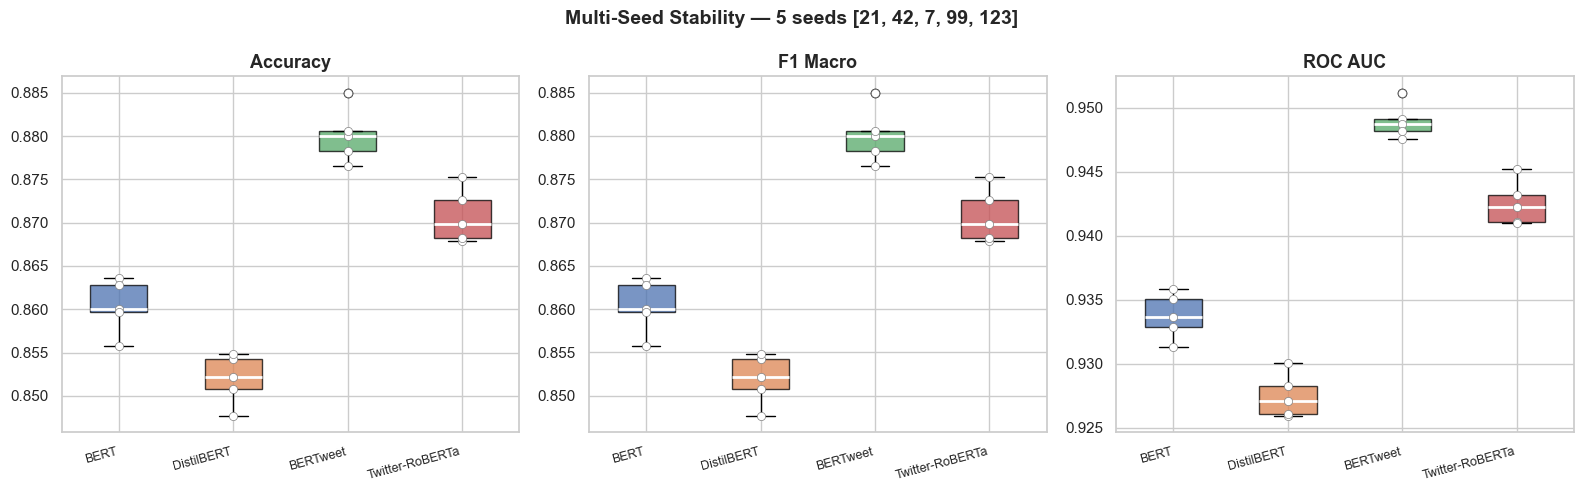

In [27]:
# Box plots — score distribution per model across seeds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = list(MODELS.keys())

for ax, metric in zip(axes, ['Accuracy', 'F1 Macro', 'ROC AUC']):
    data = [seed_df[seed_df['Model'] == name][metric].values for name in model_names]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # overlay individual seed points
    for i, d in enumerate(data):
        ax.scatter([i + 1] * len(d), d, color='white', s=35, zorder=5, edgecolors='gray', linewidths=0.5)

    ax.set_xticks(range(1, len(model_names) + 1))
    ax.set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.suptitle(f'Multi-Seed Stability — {len(SEEDS)} seeds {SEEDS}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()